In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [46]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [47]:
X , y_true = make_blobs(n_samples = 500 , centers= 3 , cluster_std= 0.60 , random_state=42)

In [48]:
df = pd.DataFrame(X , columns=['Feature_1' , 'Feature_2'])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [50]:
inertia = []
K_range = range(1 , 11)

In [51]:
for k in K_range:
    kmeans = KMeans(n_clusters= k , random_state= 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [52]:
inertia

[1000.0000000000001,
 297.8954141051722,
 11.575484723104982,
 9.752067977356843,
 8.25717527244628,
 6.917577320416798,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130397]

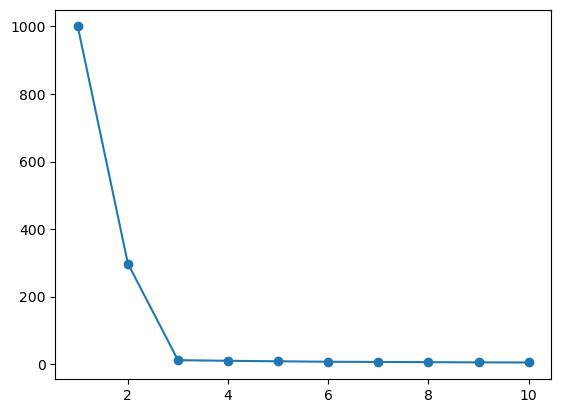

In [53]:
plt.plot(K_range , inertia , marker = 'o')

In [54]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [55]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [56]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

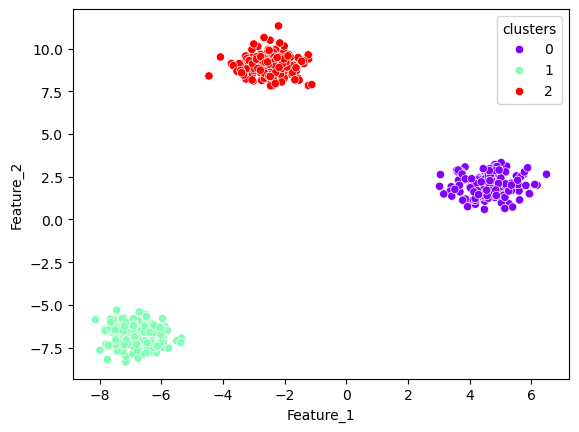

In [57]:
sns.scatterplot(x = df['Feature_1'] , y = df['Feature_2'] , hue = df['clusters'] , palette = 'rainbow')

In [58]:
df

,Feature_1,Feature_2,clusters
0,-6.190063,-7.302015,1
1,3.021747,1.940593,0
2,5.953761,1.488191,0
3,-2.744463,8.136177,2
4,5.360607,1.728324,0
...,...,...,...
495,-6.040014,-6.325329,1
496,-2.555459,9.218977,2
497,4.438408,2.974583,0
498,-7.193261,-6.250704,1


# DBSCAN CLUSTERING

In [59]:
from sklearn.datasets import make_moons

In [60]:
X_ , y_true_ = make_moons(n_samples= 500 , noise = 0.05 , random_state= 42)

In [61]:
from sklearn.cluster import DBSCAN , KMeans

In [62]:
df_ = pd.DataFrame(X_ , columns= ['feature_1' , 'feature_2'])

In [63]:
X_scaled_ = scaler.fit_transform(X_)

In [73]:
kmeans_ = KMeans(n_clusters=2 , random_state=42)
kmeans_labels = kmeans_.fit_predict(X_scaled_)

In [74]:
df_['kmeans_cluster'] = kmeans_labels

In [75]:
df_

,feature_1,feature_2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0
...,...,...,...
495,0.239754,0.985462,0
496,0.072145,0.184834,0
497,0.590273,-0.365577,1
498,1.619465,-0.283658,1


<Axes: xlabel='feature_1', ylabel='feature_2'>

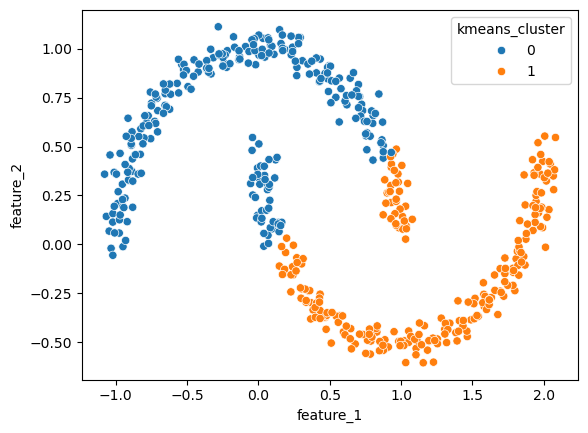

In [76]:
sns.scatterplot(x = df_['feature_1'] , y = df_['feature_2'] , hue = df_['kmeans_cluster'] , palette='tab10')

In [78]:
dbscan = DBSCAN(eps = 0.3 , min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_)

In [79]:
df_['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

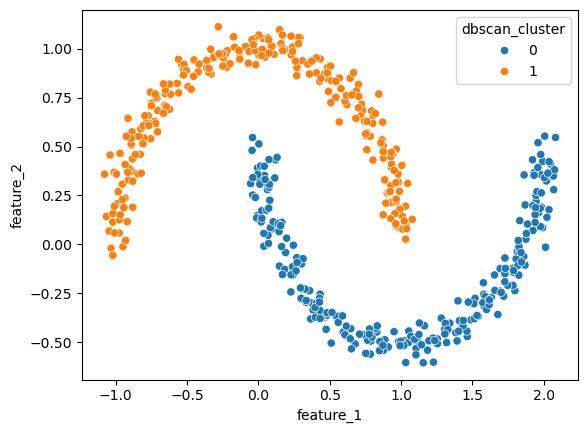

In [81]:
sns.scatterplot(x = df_['feature_1'] , y = df_['feature_2'] , hue = df_['dbscan_cluster'] ,palette='tab10')